# UNO Vision

Image Analysis and Pattern Recognition - Final Project

Group 34

Fiona Dematraz & Killian Ballifard & Gabriel Marival

**DISCLAIMER** : All scripts including this notebook expects data from kaggle to be located in **this_notebook_folder/data/\*\*** folder. Data was not included in the submission.

## 0 Setup

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

from project.scripts.dataset import load_train_images_paths_and_labels
from project.scripts.token import detect_active_player, is_white_background

from scripts.dataset import load_train_image, PARENT_PATH, CARDS_COUNT, Card
from scripts.preprocessing.sectors import slice_sectors
from scripts.preprocessing.colors import show_ref_cards_color_stats
from scripts.preprocessing.rygb import hsv2rygb, rygb2rgb
from scripts.preprocessing.filter import area_bandpass_filter
from scripts.preprocessing.crop import crop
from scripts.preprocessing import preprocess

from scripts.dataset.synthesizer import Synthesizer

## 1 Introduction

Automatically understanding the state of a game from a visual input is a complex problem that combines object detection, classification, and spatial reasoning. For the project, this problem is placed in the context of the game UNO, with the goal of inferring the complete state of a game from a single top-down photograph of the table.

From a single image, the system must predict the central card in play, the active player, and the set of cards held by each of the four players. Players occupy fixed spatial positions around the table, and the active player is indicated by a physical token placed next to their hand. The dataset presents two main difficulties: the background variability (plain white vs. noisy patterned) and the card layout complexity (non-overlapping vs. overlapping).

To address this, a pipeline was designed with two parallel branches: one for detecting the active token via color segmentation and shape filtering, and the other for card recognition, which divides the image into spatial sectors, converts them to a 4-color HSV representation, and classifies each sector using a CNN with attention pooling. The final game state is assembled by combining the two outputs and evaluated using a weighted score of center card accuracy (10%), active player accuracy (10%), and per-player F1 score (80%).

## 2 Dataset

The dataset consists of top-down photographs taken during actual UNO games, captured under a variety of conditions. There are two types of backgrounds: plain white backgrounds, which provide a clean, easy-to-segment environment, and backgrounds with busy patterns (such as a tablecloth with leaf patterns), which make isolating the cards significantly more difficult. For each background type, the dataset includes both non-overlapping and overlapping card layouts, with the latter being more challenging to process because the card edges are partially obscured.

Each image depicts up to four players positioned at fixed locations around the table (bottom, right, top, left), though not all images necessarily contain four players. In the center of the table is the active discard pile. The active player is indicated by a physical token—a small dark cube or a yellow coin—placed next to their hand of cards.

The cards fall into 54 distinct categories: number cards (0–9) in four colors (red, green, blue, yellow), as well as action cards (Pass, Reverse, Draw Two) and wild cards (Wild, Wild Draw Four).

## 3 Methodology 

### 3.1 Overview

<p align="center">
    <img src="figures/iapr_figures-Overall pipeline.png" width="700"/>
</p>

### 3.2 Active Token Detection

#### 3.2.1 Overview

The goal of this branch is to find the active player token in the image and assign it to one of the four player zones.

<p align="center">
    <img src="figures/iapr_figures-Active player.png" width="500"/>
</p>

#### 3.2.2 Step 1 : Background Detection

The first step determines which type of token to look for. The four corners of the image are sampled, which always contain background and never cards. If the mean brightness of these corners exceeds 200, the scene is classified as a white background; otherwise, it is classified as a flower background. This distinction lets know which token types are: white background always use a black rectangular token, while flower background always use a yellow circular token.

#### 3.2.3 Step 2 : Color Masking

Depending on the background type, a binary mask is computed on the full image.

- **White background** : an HSV threshold with `V < 130` and `S < 90` is applied to isolate dark pixels corresponding to the black token. Morphological closing (15×15 kernel) fills internal gaps, followed by opening (7×7 kernel) to remove noise.
- **Flower background** : the preprocessing pipeline's color segmentation function, already calibrated for UNO card colors,is used to produce a soft yellow confidence map, which is then thresholded at 40 to obtain a binary mask.

#### 3.2.4 Step 3 : Blob Selection

For each contour extracted from the binary mask, a set of shape descriptors is computed:

| Descriptor | Formula | Ideal value |
|---|---|---|
| Circularity | `4π × area / perimeter²` | 1.0 = perfect circle |
| Solidity | `area / convex_hull_area` | 1.0 = fully solid |
| Aspect ratio | `max(w,h) / min(w,h)` | 1.0 = square |
| Rect fill *(black only)* | `area / minAreaRect_area` | 1.0 = solid rectangle |
| Yellow density *(yellow only)* | fraction of yellow pixels inside blob | filters hollow symbols |

**Yellow token selection** : a candidate must satisfy:
- `circularity > 0.65` (round shape)
- `solidity > 0.65` (solid interior)
- `yellow_density > 0.55` (uniformly filled — rejects Skip card circles which have white holes)

The blob maximizing `circularity × solidity × yellow_density` is selected.

**Black token selection** : a candidate must satisfy:
- `circularity < 0.82` (non-circular, i.e. rectangular)
- `aspect_ratio > 1.1` (elongated)
- `rect_fill > 0.65` (solid rectangle, not a hollow card symbol)

Among valid candidates, the largest blob by area is retained, as the token is the biggest dark solid object in the scene.

#### 3.2.5 Step 4 : Player Assignment

The centroid `(cx, cy)` of the detected token is mapped to the nearest player zone using Euclidean distance:

```
active_player = argmin_p  distance(token_center, player_zone_center_p)
```

The four zone centers are fixed image coordinates corresponding to P1 (bottom), P2 (right), P3 (top), and P4 (left).



### 3.3 Preprocessing 

#### 3.3.1 Overview

The preprocessing pipeline takes a raw **RGB** image of shape $2662 \times 4000 \times 3$ and produces $5$ normalized **RYGB** color maps of shape $5 \times 1024 \times 2048 \times 4$, one per player zone and the center, ready to be fed into the classifier. Each step is applied independently to each sector.

<p align="center">
    <img src="figures/iapr_figures-Preprocessing.png" width="1200" />
</p>

#### 3.3.2 Step 1 : Sectors Splitting

The image is divided into $5$ fixed rectangular sectors of size $2048 \times 1024$ pixels, corresponding to the center pile and the four player zones (**P1** bottom, **P2** right, **P3** top, **P4** left). Since players are positioned on all four sides of the table, sectors for **P2**, **P3** and **P4** are rotated to a **canonical orientation** :

- **P2** (right): rotated $90$° clockwise
- **P3** (top): rotated $180$°
- **P4** (left): rotated $90$° counter-clockwise

<p align="center">
    <img src="figures/iapr_figures-Sectors.png"  width="450"/>
</p>

After reorientation, all sectors share the same $2048 \times 1024$ layout with cards always appearing in the same reading direction, giving a tensor of shape $5 \times 2048 \times 1024 \times 3$. Because sectors of that size would take too much computationnal power later on, they are **downscaled** by $4$ to $5 \times 512 \times 256 \times 3$, which leaves the card recognizable while making the size manageable.

#### 3.3.3 Step 2 : RYGB Soft Segmentation

After splitting, each sector is converted to a custom **RYGB** color space. This is more representative of the features we want to isolate.

To achieve this, each sector is first converted from **RGB** to **HSV**, which separates chromatic information (hue, saturation) from brightness (value), making color identification more robust to lighting variations.

Then cards are converted from the **HSV** color space into a custom **RYGB** color space. This is done as a **soft segmentation**, not binarizing the image, but encoding each pixel's color distance to each channel. The black component of *draw 4* and *wild* cards is computed separately using the same approach. It is then added to all four channels, so that black becomes the white of this **RYGB** color space.

<p align="center">
    <img src="figures/iapr_figures-RYGB.png" width="800"/>
</p>

The metric for this conversion is derived from the color distribution of the reference cards (manually soft segmented), by computing the **mean** and **standard deviation** of each color. For this to work, **hue** must be **wrapped around** $180$°. Then during conversion, a pixel landing on the mean color is set to $255$, while a pixel landing at $6 \cdot \sigma$ of any the characteristic is set to $0$. Any pixel within $\mu \pm 6 \cdot \sigma$ is assigned an intermediate value (except for hue and satuaration of black which are kept at $\mu \pm \sigma$, otherwise most shadows would be counted in).

#### 3.3.4 Step 3 : Area Bandpass Filtering

On images with a "flower" background, changing color space is not sufficient to completely get rid of the background. However, on the soft segmentation results, we can notice that the white contour of each card effectively separates cards regions from the background regions.

Using **region growing**, we can filter out any region with an area outside the area bands a card can occupy (around $[250, 25'000] \text{px}^2$ for $512 \times 256$ images). For this we must first **blend** all $4$ channels of the **RYGB** image together, so that regions can be counted more effectively. Then a **mask** is computed from combining regions that are within the area bands. This mask is then applied on all $4$ channels of the **RYGB** image to only keep the cards regions.

<p align="center">
    <img src="figures/iapr_figures-Background removal.png" width="700"/>
</p>

#### 3.4 Classification

#### 3.4.1 Pattern matching

Card classification is performed by **template matching** using normalized cross-correlation. For each card class $i$, a reference pattern is loaded from the card image library, downscaled by a factor of 4 using area interpolation (`cv2.INTER_AREA`), and converted to the RYGB color space.

The similarity score $s_i$ between an input image and reference pattern $i$ is computed as:

$$s_i = \frac{1}{4} \sum_{c=1}^{4} \max_{\theta,\, \lambda,\, (x,y)} R_c^{(i)}(x, y, \theta, \lambda)$$

where $R_c^{(i)}$ is the normalized cross-correlation map (`TM_CCOEFF_NORMED`) between channel $c$ of the input image and channel $c$ of the $i$-th reference pattern, after applying rotation $\theta$ and scale $\lambda$. The rotation $\theta$ is sampled uniformly over 32 values in $[-\pi, \pi)$ and the scale $\lambda$ over 8 values in $[0.9, 1.1)$. Taking the maximum over all spatial positions $(x, y)$ makes the score invariant to card location within the image.

The metric `TM_CCOEFF_NORMED` produces scores in $[-1, 1]$, where $1$ corresponds to a perfect match, independently of absolute pixel intensity. The final prediction is the class $i^* = \arg\max_i \, s_i$.

#### 3.4.2. Machine learning

## 4 Results 

### 4.1 Active player detection

The detection works reliably on both background types. On white background images, the black token produces a clean binary mask with very few false positives, as the dark rectangular shape stands out clearly. On flower background images, the yellow soft mask successfully suppresses the leaf pattern while retaining the token blob. The centroid is then correctly mapped to the nearest player zone in both cases. Examples are shown below.

Loading all train images paths with their labels
  Debug saved to /tmp/debug_image_0.png
  Debug saved to /tmp/debug_image_1.png


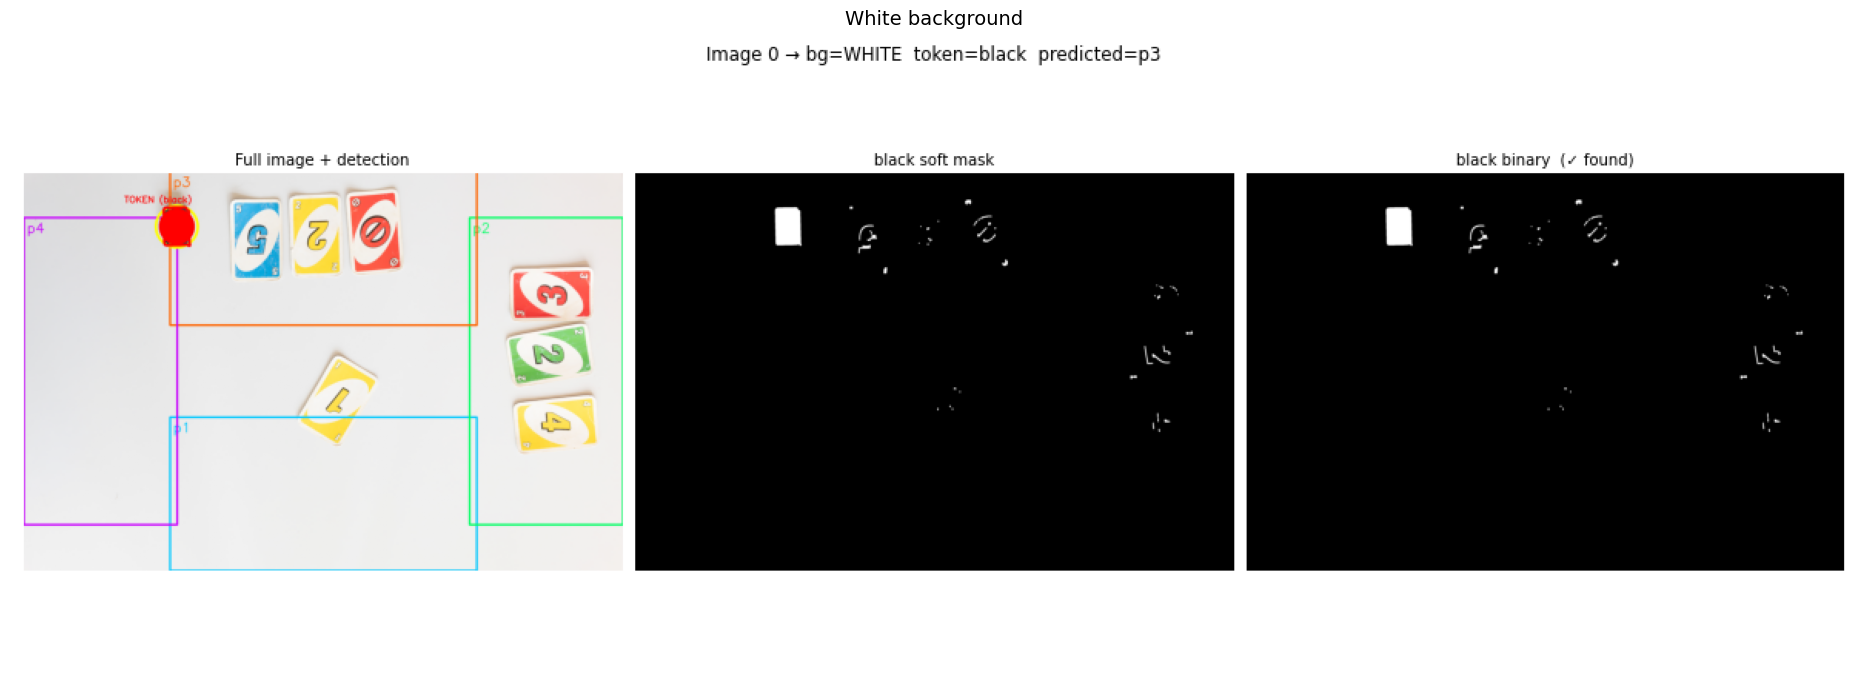

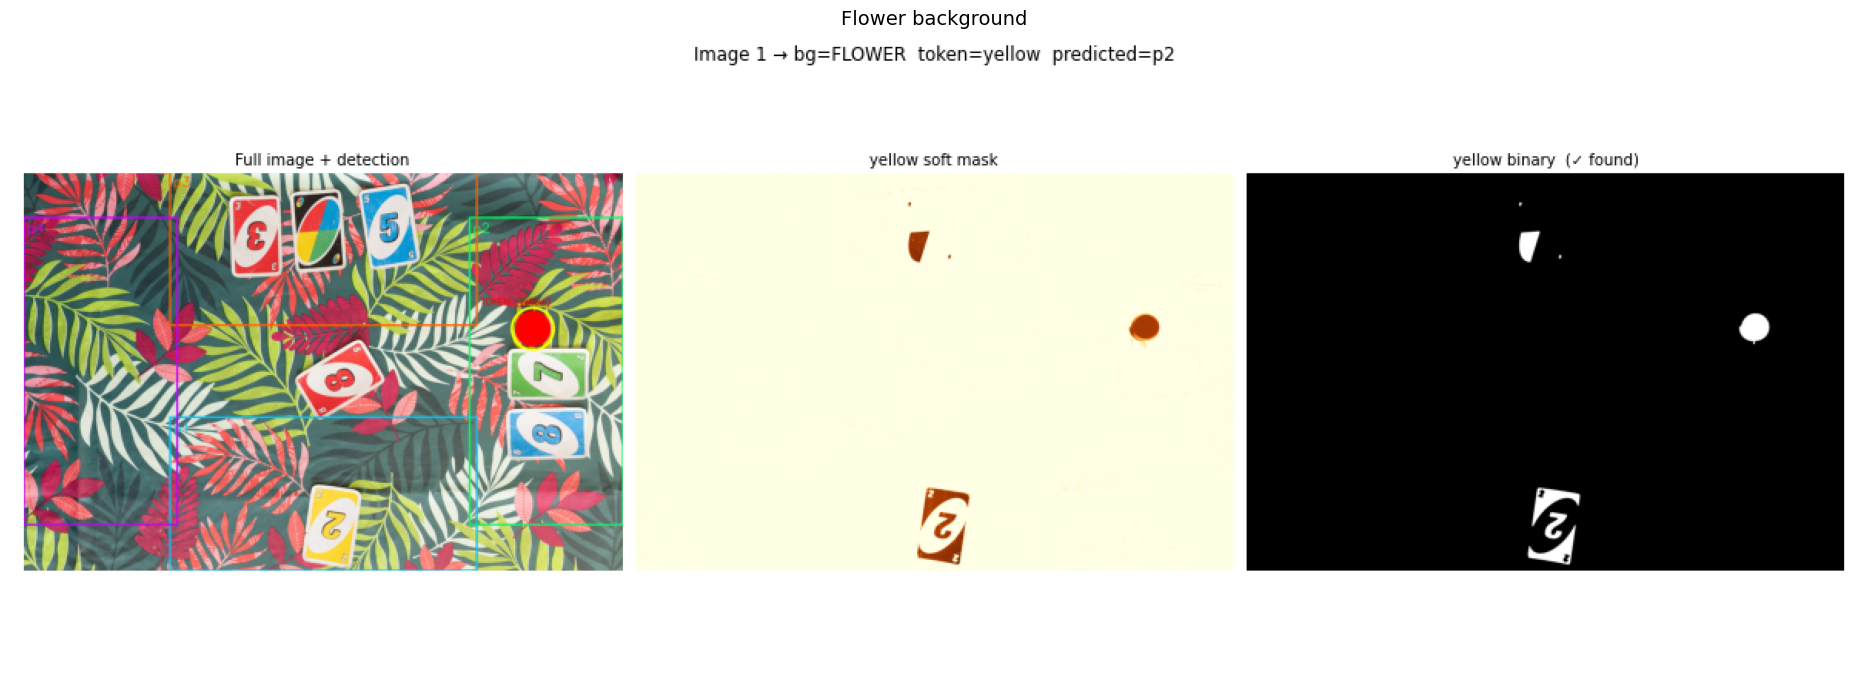

In [2]:
# Load dataset
dataset = load_train_images_paths_and_labels()

# Find one white and one flower background image
white_img, flower_img = None, None
for path, _ in dataset:
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    if white_img is None and is_white_background(img):
        white_img = img
    if flower_img is None and not is_white_background(img):
        flower_img = img
    if white_img is not None and flower_img is not None:
        break

# Run detection on both
detect_active_player([white_img, flower_img], debug=True)

# Display both inline
for i, title in enumerate(["White background", "Flower background"]):
    img = mpimg.imread(os.path.join(PARENT_PATH, "tmp", f"debug_image_{i}.png"))
    plt.figure(figsize=(20, 7))
    plt.title(title, fontsize=14)
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

The pipeline achieves 100% accuracy on the full training set of 81 images, correctly detecting and assigning the active player in all cases across both background types.

### 4.2 Preprocessing

##### 4.2.1 Step 1 : Sectors Splitting

First step is splitting the image into 5 equals sectors, making players cards attribution trivial :

Loading train image: c:\Users\killi\Desktop\iapr2026_gr34\project\data\train_images\L1000977.jpg


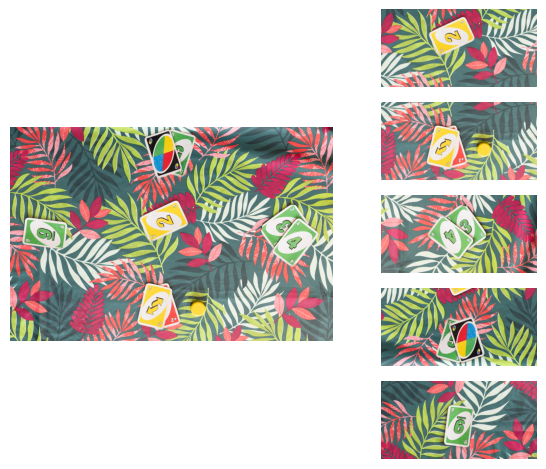

In [3]:
image = load_train_image("L1000977")
sectors = slice_sectors(image)
plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.axis("off")
for i in range(5):
    plt.subplot(5, 2, 2 * (i + 1))
    plt.imshow(sectors[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

##### 4.2.2 Step 2 : RYGB Soft Segmentation

Manual segmentation of all cards colors give a visually satisfying result, with distinguishable colors we want to find in our end images :

<p align="center">
    <img src="samples/colors/r.png" width="400"/>
    <img src="samples/colors/y.png" width="400"/>
    <img src="samples/colors/g.png" width="400"/>
    <img src="samples/colors/b.png" width="400"/>
    <img src="samples/colors/k.png" width="400"/>
</p>

Applying a more systematic approach, $\mu$ and $\sigma$ are computed from these images for each color, giving an accurate way of doing **soft segmentation** :

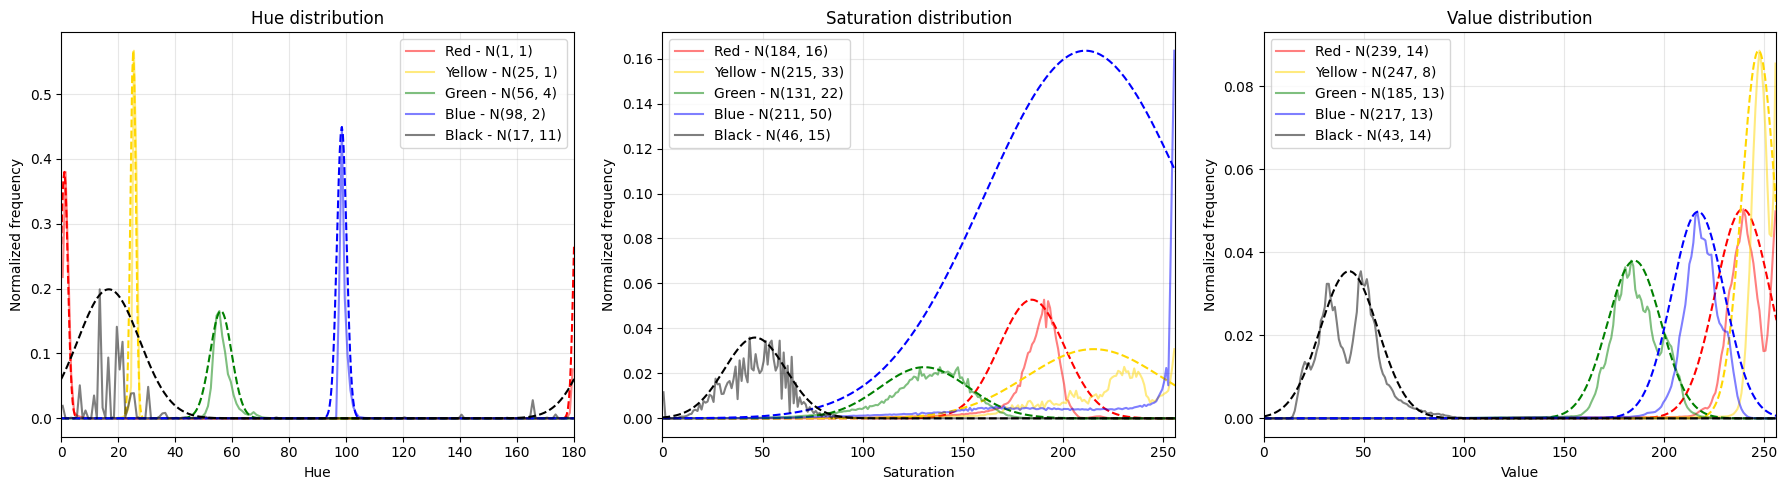

In [4]:
show_ref_cards_color_stats()

The distance heuristic was hardcoded into the `hsv2rygb` function using $\mathcal{N}(\mu, \sigma)$ to soft segment images. A secondary `rygb2rgb` brings the segmentation into a color space we can visualize :

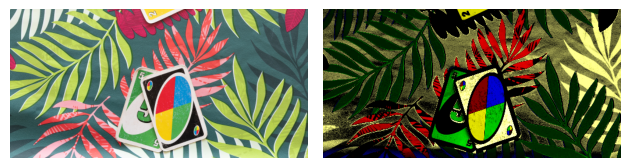

In [5]:
hsv = cv2.cvtColor(sectors[3], cv2.COLOR_RGB2HSV)   # (H, W, 3) Convert to HSV
rygb = hsv2rygb(hsv)                                # (H, W, 4) Soft segment into RYGB
rygb_preview = rygb2rgb(rygb)                       # (H, W, 3) Combine soft segmentation back into an RGB image to be able to show it on screen.
plt.figure()
plt.subplot(121)
plt.imshow(sectors[3])
plt.axis("off")
plt.subplot(122)
plt.imshow(rygb_preview)
plt.axis("off")
plt.tight_layout()
plt.show()

##### 4.2.3 Step 3 : Area Bandpass Filtering

In the code block above, when the random sampler outputs an image with a "flower" backgound, most if it remains. But the gaps left by the white contour of the cards can be used to find regions with the right surface areas :

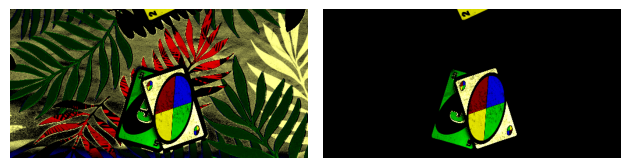

In [6]:
filtered = area_bandpass_filter(rygb)
filtered_preview = rygb2rgb(filtered)
plt.figure()
plt.subplot(121)
plt.imshow(rygb_preview)
plt.axis("off")
plt.subplot(122)
plt.imshow(filtered_preview)
plt.axis("off")
plt.tight_layout()
plt.show()

##### 4.2.4 Putting everything together

The preprocessing pipeline end to end look like follows :

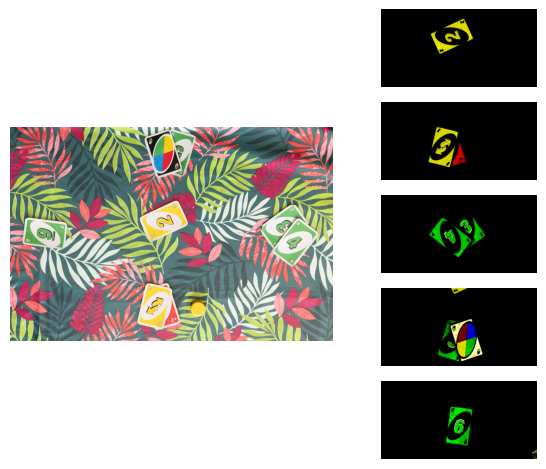

In [7]:
plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.axis("off")
for i, sector in enumerate(slice_sectors(image)):
    plt.subplot(5, 2, 2 * (i + 1))
    plt.imshow(rygb2rgb(preprocess(sector)))
    plt.axis("off")
plt.tight_layout()
plt.show()

### 4.3 Classification

#### 4.3.1 Pattern matching

#### 4.3.2 Machine learning

##### 4.3.2.1 Models Architectures

##### 4.3.2.2 Data Sythesizer

While trying to train the model, we realized that with only $81$ images, we would only have $5 \cdot 405$ sectors to train a model on. Any model would quickly overfit and thus never generalize. To address this issue, a data synthesizer was created using the cards reference images, as well as 4 backgrounds and 4 tokens of each color (for each sector).

<p align="center">
    <img src="samples/cards/b_3.png" width="200"/>
    <img src="samples/cards/g_2.png" width="200"/>
    <img src="samples/cards/g_6.png" width="200"/>
    <img src="samples/cards/b_reverse.png" width="200"/>
    <img src="samples/cards/wild.png" width="200"/>
    <img src="samples/cards/y_draw_2.png" width="200"/>
    <img src="samples/tokens/k_4.png" width="50"/>
    <img src="samples/backgrounds/gray_2.png" width="200"/>
    <img src="samples/tokens/y_1.png" width="50"/>
    <img src="samples/backgrounds/flower_4.png" width="200"/>
</p>

After combining all assert with **alpha blending** and random placement, **ambiant**, **diffuse** and **specular** lighting are applied to mimic varying lighting conditions.

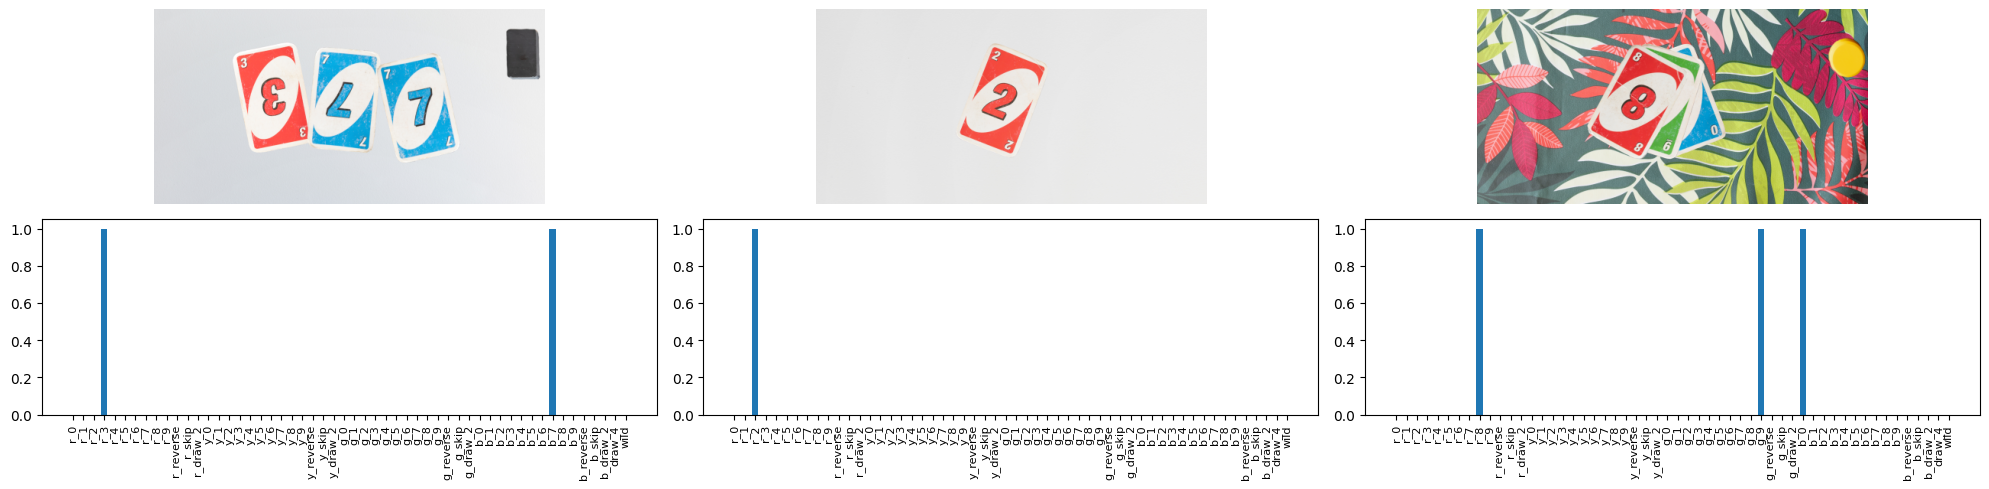

In [8]:
synthesizer = Synthesizer()
plt.figure(figsize=(20, 5))
for i in range(3):
    sector, label = synthesizer.generate()
    plt.subplot(2, 3, i + 1)
    plt.imshow(sector)
    plt.axis("off")
    plt.subplot(2, 3, i + 4)
    plt.bar(np.arange(CARDS_COUNT), label, width=0.6)
    plt.xticks(np.arange(CARDS_COUNT), [str(c) for c in Card], rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

##### 4.3.2.3 Data Cropping

One of the architecture we wanted to try is **JEPA**. For this architecture, the nework requires altered images (often cropped in random places). For this purpose a crop function was prepared, event though it never got to be used.

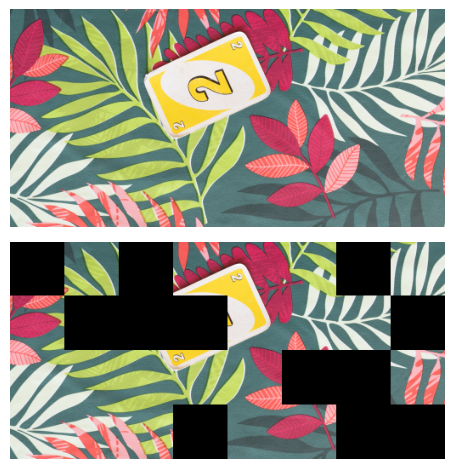

In [9]:
plt.figure()
plt.subplot(211)
plt.imshow(sectors[0])
plt.axis("off")
plt.subplot(212)
plt.imshow(crop(sectors[0]))
plt.axis("off")
plt.tight_layout()
plt.show()

## 5 Discussion

### 5.1 Active Player Detection

The active player detection pipeline behaves differently depending on the background type, and each case comes with its own difficulties.

**Background separation** 

The two background types are treated as completely separate cases since the two token types never co-occur: white backgrounds always use the black token and flower backgrounds always use the yellow token. Separating the two cases keeps each branch simple, interpretable, and independently tunable.

**White background** 

The main difficulty was that the black token is not always perfectly black. Under certain lighting conditions it appears as dark grey, falling outside the HSV threshold and causing the token to be missed. This was mitigated by widening the value threshold to capture dark grey nuances.

**Flower background** 

The yellow segmentation successfully suppresses the leaf pattern. The first challenge was that the token is not always perfectly round, so the circularity threshold was kept loose (circularity > 0.65). This however allowed the UNO yellow Skip card to pass the filter. Since the Skip card symbol is hollow while the token is uniformly filled, a yellow density filter was introduced (yellow_density > 0.55), which reliably rejects hollow card symbols while retaining the solid token.

**Limitation**

The pipeline is entirely rule-based and optimized for this specific configuration, making it highly effective under the conditions specific to the dataset, but potentially vulnerable to novel scenarios, such as new types of tokens, partial occlusions, or significantly different lighting conditions. Since the dataset is fixed and visually consistent, this specialization represents a deliberate and justified trade-off.

### 5.2 Preprocessing

### 5.3 Classification

## 7. Conclusion